In [ ]:
#Blessing Anoroh
# Project 1 - House Bill Cosponsorship Network
# Degree Centrality and Eigenvector Centrality by Party
#DATA 620 - Web Analytics
# March 9, 2026 (Due)

 **Introduction**

This analysis, we will be looking at how members of the U.S. House of Representatives collaborate through bill sponsorship and co-sponsorship. In the network, each legislator is a node and connections between them represent working together on bills. Network analysis techniques such as centrality measures and visualizations are used to understand which legislators are most connected and how collaboration happens in Congress.

I chose this dataset because it provides a clear way to study real-world collaboration and influence in government. It allows us to see how legislators work together and which members are most active in the legislative network.

Source:
U.S. House of Representatives Cosponsorship Dataset – Cornell University
https://www.cs.cornell.edu/~arb/data/house-bills/

In [1]:

# STEP 1: Import packages
# -----------------------------
import os   #to interact with operating system
from pathlib import Path
import networkx as nx   #used for network analysis ; to create graphs, centrality, and analyze relationship btwn nodes
import pandas as pd   # used for data manipulation
import matplotlib.pyplot as plt   #used for data visualization
from itertools import combinations # helps creates edges between legislators who sponsored same bill
from scipy.stats import ttest_ind #used to perform t-test



# Step 2: folder path
# -----------------------------
base_path = Path("/Users/blessinga/Desktop/Masters Data Science/Data 620 - web analytics/project 1/house-bills")

print("Folder exists:", base_path.exists())
print("Folder path:", base_path)

if base_path.exists():
    print("\nFiles in folder:")
    for f in base_path.iterdir():
        print(f.name)


# Step 3: File paths
# -----------------------------
from google.colab import files
uploaded = files.upload()
node_names_file = "/content/node-names-house-bills.txt"
node_labels_file = "/content/node-labels-house-bills.txt"
label_names_file = "/content/label-names-house-bills.txt"
hyperedges_file = "/content/hyperedges-house-bills.txt"


Folder exists: False
Folder path: /Users/blessinga/Desktop/Masters Data Science/Data 620 - web analytics/project 1/house-bills


Saving hyperedges-house-bills.txt to hyperedges-house-bills.txt
Saving label-names-house-bills.txt to label-names-house-bills.txt
Saving node-labels-house-bills.txt to node-labels-house-bills.txt
Saving node-names-house-bills.txt to node-names-house-bills.txt


In [2]:
#
# 4. Load label names
# -----------------------------
with open(label_names_file, "r", encoding="utf-8") as f:
    label_names = [line.strip() for line in f.readlines()]

label_map = {i + 1: label_names[i] for i in range(len(label_names))}
print("\nLabel map:", label_map)


# Step 5: Load node names
# -----------------------------
with open(node_names_file, "r", encoding="utf-8") as f:
    node_names = [line.strip() for line in f.readlines()]


# Step 6: Load node labels
# -----------------------------
with open(node_labels_file, "r", encoding="utf-8") as f:
    node_labels = [int(line.strip()) for line in f.readlines()]



Label map: {1: 'Democrat', 2: 'Republican'}


In [3]:

# Step 7: Create dataframe for nodes
# -----------------------------
nodes_df = pd.DataFrame({
    "node_id": range(1, len(node_names) + 1),
    "name": node_names,
    "label_id": node_labels
})

nodes_df["party"] = nodes_df["label_id"].map(label_map)

print("\nFirst 5 rows of node data:")
display(nodes_df.head())

print("\nParty counts:")
print(nodes_df["party"].value_counts())



First 5 rows of node data:


,node_id,name,label_id,party
0,1,MOSS,1,Democrat
1,2,"Dingell, John D. [MI-15]",1,Democrat
2,3,HECHLER,1,Democrat
3,4,ASHLEY,1,Democrat
4,5,CONTE,2,Republican



Party counts:
party
Democrat      792
Republican    702
Name: count, dtype: int64


In [4]:


# Step 8: Load hyperedges into Colab
# -----------------------------
hyperedges = []

with open(hyperedges_file, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            edge_nodes = [int(x) for x in line.split(",")]
            hyperedges.append(edge_nodes)

print("\nNumber of hyperedges (bills):", len(hyperedges))
print("First 5 hyperedges:")
for h in hyperedges[:5]:
    print(h)


# Step 9: Converting hypergraph to regular graph
# -----------------------------
G = nx.Graph()

for _, row in nodes_df.iterrows():
    G.add_node(row["node_id"], name=row["name"], party=row["party"])

for hedge in hyperedges:
    if len(hedge) > 1:
        for u, v in combinations(hedge, 2):
            if G.has_edge(u, v):
                G[u][v]["weight"] += 1
            else:
                G.add_edge(u, v, weight=1)

print("\nGraph summary:")
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())


Number of hyperedges (bills): 60987
First 5 hyperedges:
[1, 2]
[3, 4, 5, 6, 1, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]
[6, 27]
[28, 29]
[30, 31, 32, 33, 34, 35, 36, 37, 23, 38, 39, 40]

Graph summary:
Number of nodes: 1494
Number of edges: 496082




**This means the dataset contains 60,987 bills.**

* Nodes = Members of Congress
* Hyperedges = Bills

 In a hypergraph, a hyperedge can connect many nodes at once.

**Looking at the first 5 bills we can see:**

* Bill 1: Sponsored by legislators 1 and 2.

* Bill 2: Sponsored by legislators 3–26, showing a bill with many cosponsors.

* Bill 3: Sponsored by legislators 6 and 27.

* Bill 4: Sponsored by legislators 28 and 29.

* Bill 5: Sponsored by legislators 30, 31, 32, 33, 34, 35, 36, 37, 23, 38, 39, and 40, showing collaboration among multiple members.


**Number of nodes: 1494**

  -This means there are 1,494 legislators in this dataset.

  -Each node represents one member of Congress.


**Number of edges: 496,082**

  -Edges represent connections between legislators.

  -Two legislators are connected if they worked on the same bill.

In [5]:


# Step 10: Calculate centrality measures
# -----------------------------
degree_centrality = nx.degree_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)

nodes_df["degree_centrality"] = nodes_df["node_id"].map(degree_centrality)
nodes_df["eigenvector_centrality"] = nodes_df["node_id"].map(eigenvector_centrality)

print("\nCentrality results:")
display(nodes_df.head())


Centrality results:


,node_id,name,label_id,party,degree_centrality,eigenvector_centrality
0,1,MOSS,1,Democrat,0.364367,0.016652
1,2,"Dingell, John D. [MI-15]",1,Democrat,0.971869,0.047337
2,3,HECHLER,1,Democrat,0.347622,0.015155
3,4,ASHLEY,1,Democrat,0.427997,0.020813
4,5,CONTE,2,Republican,0.687877,0.035013


Centrality measures help identify the most connected and influential legislators in the bill sponsorship network. Degree centrality shows how many other members a legislator collaborated with on bills, while eigenvector centrality measures influence based on connections to other well-connected legislators. **The results show that John Dingell has the highest centrality values at 0.97, suggesting he played a major role in collaboration and influence within the congressional sponsorship network.**

In [6]:

# Step 11: Compare by party (Analysis)
# -----------------------------
group_summary = nodes_df.groupby("party")[["degree_centrality", "eigenvector_centrality"]].agg(["mean", "std", "median", "count"])
print("\nSummary statistics by party:")
display(group_summary)



Summary statistics by party:


degree_centrality                           eigenvector_centrality  \
                        mean       std    median count                   mean   
party                                                                           
Democrat            0.459691  0.169280  0.424648   792               0.024954   
Republican          0.428018  0.161376  0.395847   702               0.023341   

                                      
                 std    median count  
party                                 
Democrat    0.009258  0.024046   792  
Republican  0.008984  0.022067   702

Looking at this statistics by party:

Democrats have slightly higher average degree centrality, meaning they collaborated with more legislators on average.

Democrats also show slightly higher eigenvector centrality, suggesting somewhat greater influence within the sponsorship network.

However, the differences between the two parties are relatively small, indicating that collaboration patterns are fairly similar across parties.

In [7]:

# Step 12: T-tests
# -----------------------------
democrats = nodes_df[nodes_df["party"] == "Democrat"]
republicans = nodes_df[nodes_df["party"] == "Republican"]

degree_ttest = ttest_ind(
    democrats["degree_centrality"],
    republicans["degree_centrality"],
    equal_var=False
)

eigen_ttest = ttest_ind(
    democrats["eigenvector_centrality"],
    republicans["eigenvector_centrality"],
    equal_var=False
)

print("\nT-Test Results")
print("Degree Centrality t-test:")
print("t-statistic =", degree_ttest.statistic)
print("p-value     =", degree_ttest.pvalue)

print("\nEigenvector Centrality t-test:")
print("t-statistic =", eigen_ttest.statistic)
print("p-value     =", eigen_ttest.pvalue)



T-Test Results
Degree Centrality t-test:
t-statistic = 3.699917321654813
p-value     = 0.00022354426706258282

Eigenvector Centrality t-test:
t-statistic = 3.415465047071415
p-value     = 0.0006539601117555263


In [8]:

# Interpretation T-test
# -----------------------------
alpha = 0.05

print("\nInterpretation:")
if degree_ttest.pvalue < alpha:
    print("There is a statistically significant difference in degree centrality between parties.")
else:
    print("There is no statistically significant difference in degree centrality between parties.")

if eigen_ttest.pvalue < alpha:
    print("There is a statistically significant difference in eigenvector centrality between parties.")
else:
    print("There is no statistically significant difference in eigenvector centrality between parties.")



Interpretation:
There is a statistically significant difference in degree centrality between parties.
There is a statistically significant difference in eigenvector centrality between parties.


**T-Test Results**

***Degree Centrality***

t-statistic: 3.6999

p-value: 0.00022

* The p-value is much smaller than 0.05,
meaning the difference in degree centrality between Democrats and Republicans is statistically significant.


**Eigenvector Centrality**

t-statistic: 3.4155

p-value: 0.00065

The p-value is also less than 0.05, indicating a statistically significant difference in eigenvector centrality between the two parties.

In [9]:

# Step 13: Top legislators by degree centrality
# -----------------------------
top_degree = nodes_df.sort_values("degree_centrality", ascending=False)[
    ["name", "party", "degree_centrality"]
].head(10)

print("\nTop 10 legislators by degree centrality:")
display(top_degree)


#
# The purpose of identifying the top 10 legislators by degree centrality is to
# determine which members of Congress collaborate with the largest number of other legislators
# through bill sponsorship.



Top 10 legislators by degree centrality:


,name,party,degree_centrality
23,STARK,Democrat,0.985934
72,CONYERS,Democrat,0.978567
102,"Rangel, Charles B. [NY-15]",Democrat,0.976557
160,YOUNG (GA.),Republican,0.973208
178,YOUNG (FLA.),Republican,0.973208
1,"Dingell, John D. [MI-15]",Democrat,0.971869
245,REGULA,Republican,0.971199
17,OBEY,Democrat,0.965841
216,"Crane, Philip M. [IL-8]",Republican,0.964501
430,MURTHA,Democrat,0.959143


In [10]:


# Step 14: Top legislators by eigenvector centrality
# -----------------------------
top_eigen = nodes_df.sort_values("eigenvector_centrality", ascending=False)[
    ["name", "party", "eigenvector_centrality"]
].head(10)

print("\nTop 10 legislators by eigenvector centrality:")
display(top_eigen)


#The purpose of identifying the top 10 legislators by eigenvector centrality
#is to find the most influential members in the network.



Top 10 legislators by eigenvector centrality:


,name,party,eigenvector_centrality
23,STARK,Democrat,0.047645
72,CONYERS,Democrat,0.047506
102,"Rangel, Charles B. [NY-15]",Democrat,0.047483
160,YOUNG (GA.),Republican,0.047412
245,REGULA,Republican,0.047362
178,YOUNG (FLA.),Republican,0.047360
1,"Dingell, John D. [MI-15]",Democrat,0.047337
430,MURTHA,Democrat,0.047158
216,"Crane, Philip M. [IL-8]",Republican,0.047107
17,OBEY,Democrat,0.047094


**Top 3 Legislators by Degree Centrality**

* Pete Stark (Democrat) - 0.9859
* John Conyers (Democrat) - 0.9786
* Charles B. Rangel (Democrat) - 0.9766

Explanation:
These three legislators have the highest degree centrality, meaning they collaborated with the largest number of other members in the bill sponsorship network. This suggests they were highly connected and active in legislative collaborations compared to other members of Congress.

<Figure size 800x500 with 0 Axes>

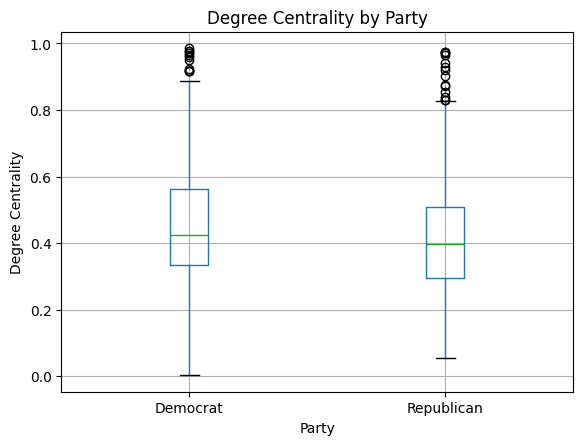

<Figure size 800x500 with 0 Axes>

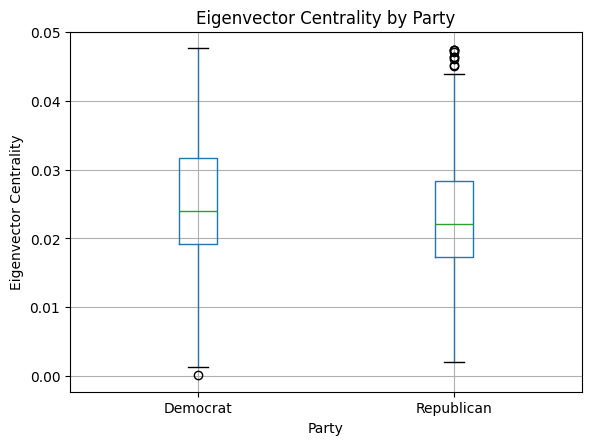

In [11]:

#Step 15: Boxplots
# -----------------------------
#to visualize the distribution of centrality values across parties.

plt.figure(figsize=(8, 5))
nodes_df.boxplot(column="degree_centrality", by="party")
plt.title("Degree Centrality by Party")
plt.suptitle("")
plt.xlabel("Party")
plt.ylabel("Degree Centrality")
plt.show()

plt.figure(figsize=(8, 5))
nodes_df.boxplot(column="eigenvector_centrality", by="party")
plt.title("Eigenvector Centrality by Party")
plt.suptitle("")
plt.xlabel("Party")
plt.ylabel("Eigenvector Centrality")
plt.show()

**Degree Centrality Box Plot:**

This box plot displays the distribution of degree centrality values for legislators by party. The median degree centrality for Democrats is slightly higher than for Republican; meaning they collaborate with more colleaguees on average . There are also several outliers at the top of the distribution.


**Eigenvector centrality Box Plot:**

This box plot shows the distribution of eigenvector centrality values for legislators in each party. The median values for both Democrats and Republicans are very similar, s

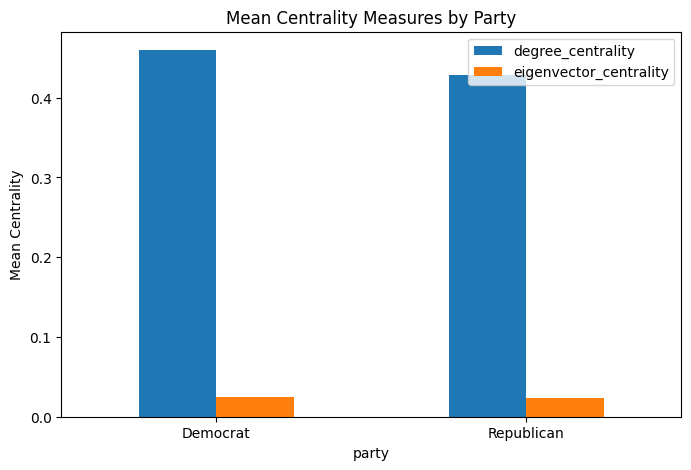

In [12]:

#Step 16: Bar chart of mean centralities
# -----------------------------

mean_values = nodes_df.groupby("party")[["degree_centrality", "eigenvector_centrality"]].mean()

mean_values.plot(kind="bar", figsize=(8, 5))
plt.title("Mean Centrality Measures by Party")
plt.ylabel("Mean Centrality")
plt.xticks(rotation=0)
plt.show()


#formula : Cˉ=n1​i=1∑n​Ci​ ; sum of centraility values /(divided) # of nodes


This bar chart compares the average degree centrality and eigenvector centrality for Democrats and Republicans. The chart shows that Democrats have slightly higher average degree and eigenvector centrality values than Republicans.

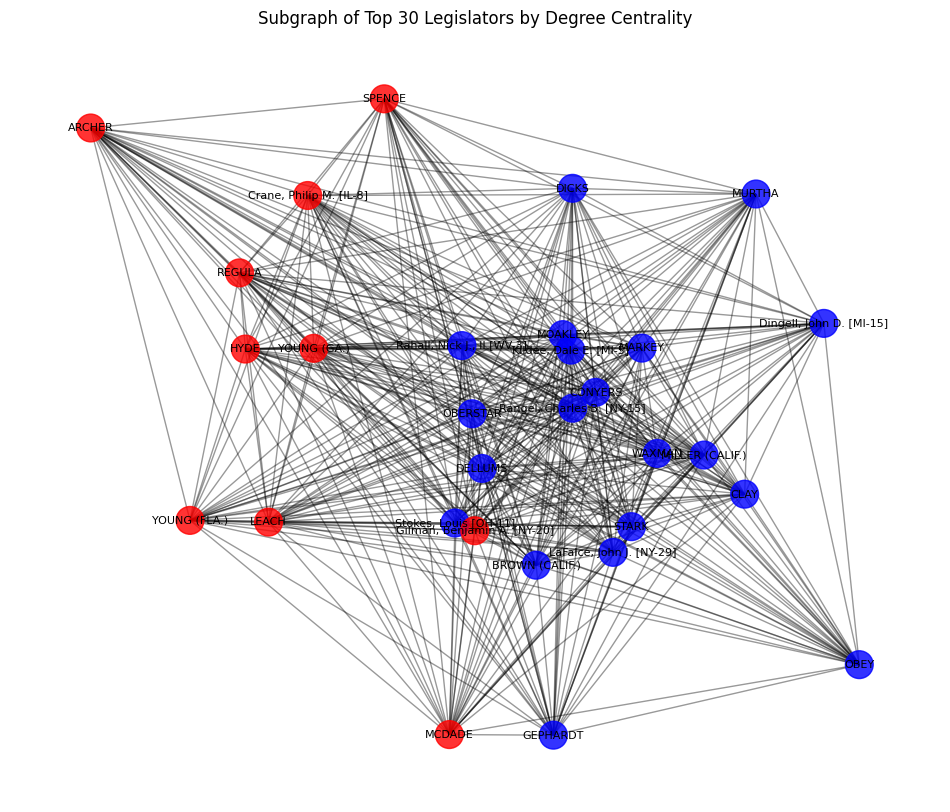

In [13]:
# Step 17: Subgraph of top legislators
# -----------------------------
#The purpose of creating the is to focus on a smaller, more meaningful
#part of the network instead of analyzing the entire graph.

top_nodes = nodes_df.sort_values("degree_centrality", ascending=False).head(30)["node_id"].tolist()
H = G.subgraph(top_nodes)

party_colors = []
for node in H.nodes():
    if G.nodes[node]["party"] == "Democrat":
        party_colors.append("blue")
    else:
        party_colors.append("red")

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(H, seed=42)
nx.draw_networkx_nodes(H, pos, node_color=party_colors, node_size=400, alpha=0.8)
nx.draw_networkx_edges(H, pos, alpha=0.4)
nx.draw_networkx_labels(
    H,
    pos,
    labels={node: G.nodes[node]["name"] for node in H.nodes()},
    font_size=8
)
plt.title("Subgraph of Top 30 Legislators by Degree Centrality")
plt.axis("off")
plt.show()



This network graph shows the top 30 legislators with the highest degree centrality in the bill sponsorship network. Each node represents a legislator, and edges represent collaboration through bill sponsorship or cosponsorship. The colors indicate political party affiliation.

* Blue: Democrat
* Red: Republicans

**RESEARCH QUESTIONS To Answer after Analyzing:**

1.Do members of the majority party have more connections than members of the minority party?
Yes. The results show that Democrats have slightly higher average degree centrality,

2. Does having more connections relate to greater influence?
Yes. Legislators with higher degree centrality, such as Pete Stark, John Conyers, and Charles B. Rangel, also tend to have higher influence in the network because they collaborate with many other members.

3. Do Democrats and Republicans collaborate differently?
Democrats had slightly higher average centrality, but both parties show similar collaboration patterns.

**Conclusion**

This project analyzed a congressional bill sponsorship network to understand collaboration between legislators. Centrality measures showed that a few legislators, such as Pete Stark, John Conyers, and Charles B. Rangel, were highly connected and collaborated with many others. While Democrats had slightly higher average centrality values than Republicans, collaboration occurred across both parties. Overall, the analysis shows that legislative work is supported by a network of collaborations, where a small number of highly connected members help link many legislators together.